# Exercises : Tranfer leanring part 2 - Fine Tuning

## 1.1 Get data

In [1]:
import zipfile
import tensorflow as tf
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

# Unzip data
with zipfile.ZipFile('10_food_classes_10_percent.zip') as zipref:
  zipref.extractall()

--2026-05-16 07:31:11--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.145.207, 74.125.128.207, 74.125.143.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.145.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M  29.4MB/s    in 6.1s    

2026-05-16 07:31:17 (26.1 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [2]:
import os

for dirpath, dirnames, filenames in os.walk('10_food_classes_10_percent'):
  print(f'There are {len(dirnames)} folders and {len(filenames)} files in the folder: {dirpath}')

There are 2 folders and 0 files in the folder: 10_food_classes_10_percent
There are 10 folders and 0 files in the folder: 10_food_classes_10_percent/train
There are 0 folders and 75 files in the folder: 10_food_classes_10_percent/train/ramen
There are 0 folders and 75 files in the folder: 10_food_classes_10_percent/train/grilled_salmon
There are 0 folders and 75 files in the folder: 10_food_classes_10_percent/train/sushi
There are 0 folders and 75 files in the folder: 10_food_classes_10_percent/train/hamburger
There are 0 folders and 75 files in the folder: 10_food_classes_10_percent/train/chicken_wings
There are 0 folders and 75 files in the folder: 10_food_classes_10_percent/train/fried_rice
There are 0 folders and 75 files in the folder: 10_food_classes_10_percent/train/steak
There are 0 folders and 75 files in the folder: 10_food_classes_10_percent/train/ice_cream
There are 0 folders and 75 files in the folder: 10_food_classes_10_percent/train/chicken_curry
There are 0 folders and 

In [3]:
train_dir_10_percent = '10_food_classes_10_percent/train/'
test_dir = '10_food_classes_10_percent/test/'

IMG_SIZE = (224,224)
BATCH_SIZE = 32

# Get it into dataloaders
train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir_10_percent,
    label_mode='categorical',
    image_size=IMG_SIZE,
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode='categorical',
    image_size=IMG_SIZE
)

Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [4]:
class_names = train_data_10_percent.class_names

## 1.2 Model initialization

In [5]:
from tensorflow.keras import layers, Sequential
from tensorflow.keras import applications

In [6]:
base_model = applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = False
data_augmentation = Sequential([
    layers.RandomRotation(0.2),
    layers.RandomWidth(0.2),
    layers.RandomHeight(0.2),
    layers.RandomFlip('horizontal'),
    layers.RandomZoom(0.2),
    layers.RandomHue(0.1)
])
inputs = layers.Input(shape=IMG_SIZE+(3,),name='input_layer')
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name='GAP_layer')(x)
outputs = layers.Dense(len(class_names), activation='softmax',name='output_layer')(x)
model_1 = tf.keras.Model(inputs,outputs,name='Model_1')

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
# compile and train model
model_1.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

In [8]:
from tensorflow.keras.callbacks import TensorBoard

def create_tensorboard_callback(dir_name,experiment_name):
  tensorboard = TensorBoard(log_dir=dir_name+'/'+experiment_name,
                            update_freq='epoch')
  return tensorboard

In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint

def create_checkpoint_callback(filepath, save_weights_only, metrics='val_accuracy'):
  checkpoint = ModelCheckpoint(filepath=filepath+'.weights.h5',
                               save_weights_only=save_weights_only,
                               monitor=metrics)
  return checkpoint

In [10]:
filepath = 'fine_tuning_exercises'
save_weights_only = True
metrics = 'val_accuracy'
dir_name = 'fine_tuning'
experiment_name_1 = 'model_1'
initial_epochs=10

In [11]:
history_1 = model_1.fit(
    train_data_10_percent,
    steps_per_epoch=len(train_data_10_percent),
    validation_data=test_data,
    validation_steps=int(0.25 * len(test_data)),
    epochs=initial_epochs,
    callbacks=[create_checkpoint_callback(filepath, save_weights_only, metrics),
               create_tensorboard_callback(dir_name,experiment_name_1)]
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 33s 626ms/step - accuracy: 0.3187 - loss: 2.0297 - val_accuracy: 0.5938 - val_loss: 1.5501
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 867ms/step - accuracy: 0.5947 - loss: 1.4926 - val_accuracy: 0.7237 - val_loss: 1.1349
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 461ms/step - accuracy: 0.6747 - loss: 1.2031 - val_accuracy: 0.7566 - val_loss: 0.9203
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 474ms/step - accuracy: 0.7240 - loss: 1.0331 - val_accuracy: 0.8109 - val_loss: 0.7746
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 453ms/step - accuracy: 0.7680 - loss: 0.9181 - val_accuracy: 0.8289 - val_loss: 0.6945
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 413ms/step - accuracy: 0.7733 - loss: 0.8542 - val_accuracy: 0.8257 - val_loss: 0.6451
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 425ms/step - accuracy: 0.7747 - loss: 0.7982 - val_accuracy: 0.8339 - val_loss: 0.6026
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 408ms/step - accuracy: 0.7893 - loss: 0.7439 - val_accu

In [12]:
history_1.history

{'accuracy': [0.3186666667461395,
  0.5946666598320007,
  0.6746666431427002,
  0.7239999771118164,
  0.7680000066757202,
  0.7733333110809326,
  0.7746666669845581,
  0.7893333435058594,
  0.8040000200271606,
  0.7906666398048401],
 'loss': [2.0296828746795654,
  1.4926202297210693,
  1.2031021118164062,
  1.0330575704574585,
  0.9181225299835205,
  0.8541632294654846,
  0.7982269525527954,
  0.7438672780990601,
  0.7166814208030701,
  0.7043561935424805],
 'val_accuracy': [0.59375,
  0.7236841917037964,
  0.7565789222717285,
  0.8108552694320679,
  0.8289473652839661,
  0.8256579041481018,
  0.8338815569877625,
  0.8421052694320679,
  0.8404605388641357,
  0.84375],
 'val_loss': [1.5501152276992798,
  1.13493013381958,
  0.9203357696533203,
  0.7746041417121887,
  0.6945419907569885,
  0.6451250314712524,
  0.602552056312561,
  0.5551231503486633,
  0.5423519015312195,
  0.5315254926681519]}

In [13]:
history_1.epoch

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [14]:
import matplotlib.pyplot as plt

def plot_loss_curves(history):
  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs= history.epoch

  plt.plot(epochs, accuracy, c='b', label='Training Accuracy')
  plt.plot(epochs, val_accuracy, c='y', label='Validation Accuracy')
  plt.ylabel('Epochs')
  plt.xlabel('Accuracy')
  plt.title('Accuracy Curves')
  plt.legend(loc='lower right')

  plt.figure()
  plt.plot(epochs, loss,  c='b', label='Training Loss')
  plt.plot(epochs, val_loss,  c='y', label='Validation Loss')
  plt.ylabel('Epochs')
  plt.xlabel('Loss')
  plt.title('Loss Curves')
  plt.legend(loc='upper right')

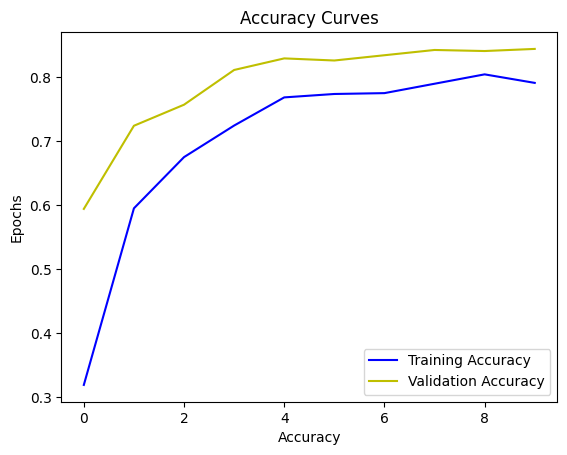

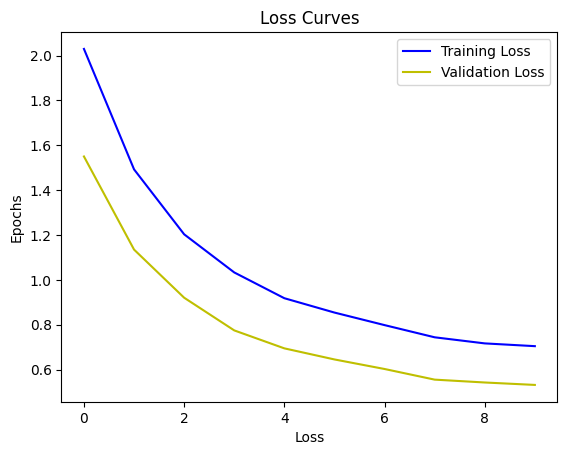

In [15]:
plot_loss_curves(history_1)

In [16]:
model_1_results = model_1.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - accuracy: 0.8464 - loss: 0.5303


[0.5303468704223633, 0.8464000225067139]

## Model 2: Fine-Tuning for 10 more epochs

In [17]:
model_1.load_weights(filepath+'.weights.h5')

In [18]:
model_1.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.8464 - loss: 0.5303


[0.5303468108177185, 0.8464000225067139]

In [19]:
for i,layer in enumerate(model_1.layers[2].layers):
  print(i, layer.name, layer.trainable)

0 input_layer False
1 rescaling False
2 normalization False
3 stem_conv False
4 stem_bn False
5 stem_activation False
6 block1a_project_conv False
7 block1a_project_bn False
8 block1a_project_activation False
9 block2a_expand_conv False
10 block2a_expand_bn False
11 block2a_expand_activation False
12 block2a_project_conv False
13 block2a_project_bn False
14 block2b_expand_conv False
15 block2b_expand_bn False
16 block2b_expand_activation False
17 block2b_project_conv False
18 block2b_project_bn False
19 block2b_drop False
20 block2b_add False
21 block3a_expand_conv False
22 block3a_expand_bn False
23 block3a_expand_activation False
24 block3a_project_conv False
25 block3a_project_bn False
26 block3b_expand_conv False
27 block3b_expand_bn False
28 block3b_expand_activation False
29 block3b_project_conv False
30 block3b_project_bn False
31 block3b_drop False
32 block3b_add False
33 block4a_expand_conv False
34 block4a_expand_bn False
35 block4a_expand_activation False
36 block4a_dwconv2 

In [20]:
for layer in model_1.layers[2].layers[-20:]:
  layer.trainable = True

In [21]:
model_1.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

In [22]:
fine_tune_epochs=initial_epochs+10
filepath = 'fine_tuning_exercises_pt2'
save_weights_only = True
metrics = 'val_accuracy'
dir_name = 'fine_tuning'
experiment_name_2 = 'model_2'
initial_epochs=10

history_2 = model_1.fit(
    train_data_10_percent,
    steps_per_epoch=len(train_data_10_percent),
    validation_data=test_data,
    initial_epoch=history_1.epoch[-1],
    epochs=fine_tune_epochs,
    validation_steps=int(0.25 * len(test_data)),
    callbacks=[create_checkpoint_callback(filepath,save_weights_only,metrics),
               create_tensorboard_callback(dir_name=dir_name,
                                           experiment_name=experiment_name_2)]
)

Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 37s 670ms/step - accuracy: 0.7840 - loss: 0.8628 - val_accuracy: 0.8405 - val_loss: 0.5784
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 400ms/step - accuracy: 0.8133 - loss: 0.7967 - val_accuracy: 0.8438 - val_loss: 0.5645
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 394ms/step - accuracy: 0.8133 - loss: 0.7563 - val_accuracy: 0.8536 - val_loss: 0.5201
Epoch 13/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 405ms/step - accuracy: 0.8427 - loss: 0.6775 - val_accuracy: 0.8586 - val_loss: 0.5056
Epoch 14/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 432ms/step - accuracy: 0.8467 - loss: 0.6454 - val_accuracy: 0.8569 - val_loss: 0.4860
Epoch 15/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 381ms/step - accuracy: 0.8480 - loss: 0.6254 - val_accuracy: 0.8569 - val_loss: 0.4848
Epoch 16/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 448ms/step - accuracy: 0.8240 - loss: 0.6450 - val_accuracy: 0.8586 - val_loss: 0.4607
Epoch 17/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 381ms/step - accuracy: 0.8627 - loss: 0.5698 - va

In [23]:
# evaluate model_2
model_2_results = model_1.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.8732 - loss: 0.4122


[0.41219303011894226, 0.873199999332428]

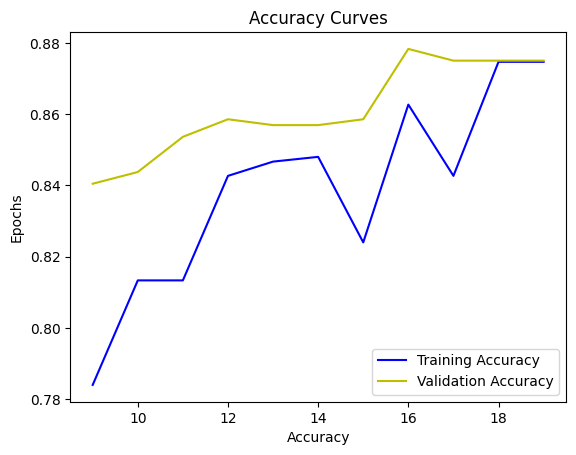

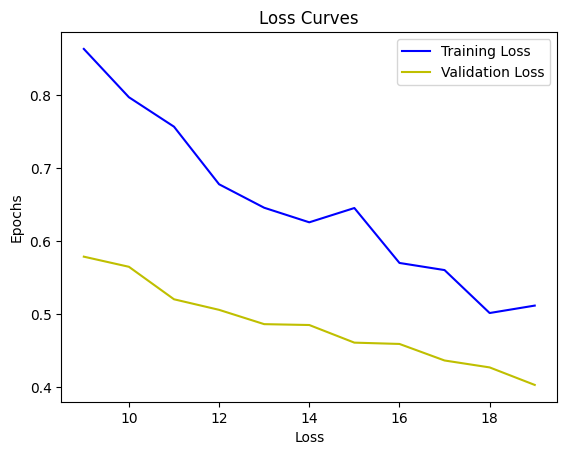

In [25]:
plot_loss_curves(history_2)

## Model 3: Fine tune last 30 layers

In [106]:
# Revert the model_1 to featuer extraction only
filepath = 'fine_tuning_exercises.weights.h5'
model_1.load_weights(filepath)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 58 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [34]:
model_1.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.8464 - loss: 0.5303


[0.5303467512130737, 0.8464000225067139]

In [35]:
for layer in model_1.layers[2].layers[-30:]:
  layer.trainable=True

In [36]:
for i,layer in enumerate(model_1.layers[2].layers):
  print(i,layer.name,layer.trainable)

0 input_layer False
1 rescaling False
2 normalization False
3 stem_conv False
4 stem_bn False
5 stem_activation False
6 block1a_project_conv False
7 block1a_project_bn False
8 block1a_project_activation False
9 block2a_expand_conv False
10 block2a_expand_bn False
11 block2a_expand_activation False
12 block2a_project_conv False
13 block2a_project_bn False
14 block2b_expand_conv False
15 block2b_expand_bn False
16 block2b_expand_activation False
17 block2b_project_conv False
18 block2b_project_bn False
19 block2b_drop False
20 block2b_add False
21 block3a_expand_conv False
22 block3a_expand_bn False
23 block3a_expand_activation False
24 block3a_project_conv False
25 block3a_project_bn False
26 block3b_expand_conv False
27 block3b_expand_bn False
28 block3b_expand_activation False
29 block3b_project_conv False
30 block3b_project_bn False
31 block3b_drop False
32 block3b_add False
33 block4a_expand_conv False
34 block4a_expand_bn False
35 block4a_expand_activation False
36 block4a_dwconv2 

In [37]:
model_1.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

In [38]:
fine_tune_epochs=initial_epochs+10
filepath = 'fine_tuning_exercises_pt3'
save_weights_only = True
metrics = 'val_accuracy'
dir_name = 'fine_tuning'
experiment_name_3 = 'model_3'
initial_epochs=10

history_3 = model_1.fit(
    train_data_10_percent,
    steps_per_epoch=len(train_data_10_percent),
    validation_data=test_data,
    validation_steps=int(0.25 * len(test_data)),
    epochs=fine_tune_epochs,
    initial_epoch=history_1.epoch[-1],
    callbacks=[create_checkpoint_callback(filepath,save_weights_only,metrics),
               create_tensorboard_callback(dir_name,experiment_name_3)]
)

Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 516ms/step - accuracy: 0.7720 - loss: 0.9301 - val_accuracy: 0.8405 - val_loss: 0.5840
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 350ms/step - accuracy: 0.8240 - loss: 0.7751 - val_accuracy: 0.8339 - val_loss: 0.5559
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 309ms/step - accuracy: 0.8160 - loss: 0.7464 - val_accuracy: 0.8553 - val_loss: 0.4949
Epoch 13/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 354ms/step - accuracy: 0.8240 - loss: 0.6902 - val_accuracy: 0.8651 - val_loss: 0.4786
Epoch 14/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 320ms/step - accuracy: 0.8427 - loss: 0.6457 - val_accuracy: 0.8766 - val_loss: 0.4590
Epoch 15/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 432ms/step - accuracy: 0.8653 - loss: 0.5815 - val_accuracy: 0.8701 - val_loss: 0.4448
Epoch 16/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 425ms/step - accuracy: 0.8480 - loss: 0.5984 - val_accuracy: 0.8717 - val_loss: 0.4477
Epoch 17/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 356ms/step - accuracy: 0.8627 - loss: 0.5456 - val_

In [40]:
model_3_results = model_1.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.8744 - loss: 0.4200


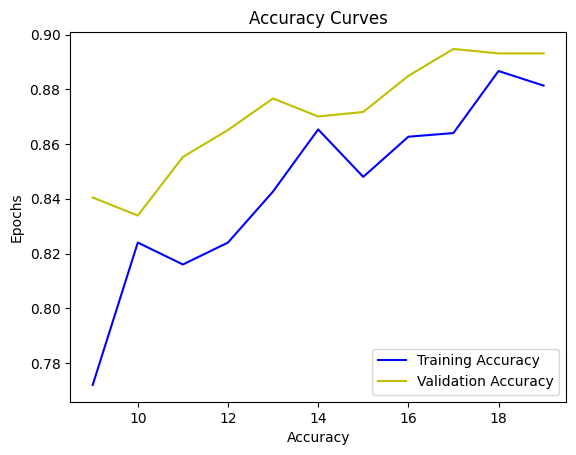

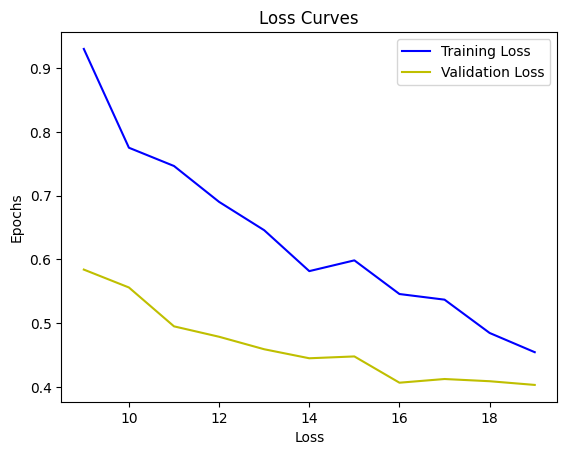

In [39]:
plot_loss_curves(history_3)

In [54]:
import random
from pathlib import Path

image_list = list(Path('10_food_classes_10_percent').glob('*/*/*'))
len(image_list)
image_list[0]

PosixPath('10_food_classes_10_percent/train/ramen/3885045.jpg')

In [57]:
image_list[0].parent.stem

'ramen'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Raw probs: [[2.9343460e-03 7.4607992e-01 1.1848968e-03 4.2747017e-02 2.8713603e-02
  2.6018851e-04 8.3608238e-04 1.0066715e-04 1.7588188e-01 1.2613570e-03]]
Pred index: 1
Pred class: chicken_wings
Ground truth: chicken_wings


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

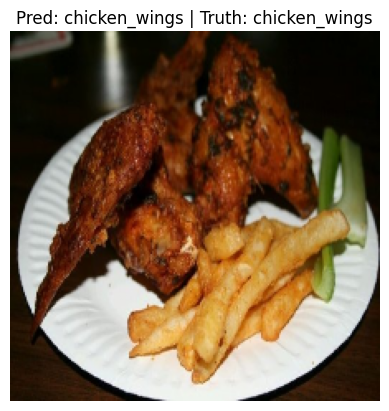

In [125]:
import matplotlib.image as mpimg

random_image = random.choice(image_list)
random_image_label = random_image.parent.stem

image = mpimg.imread(random_image)
image = tf.image.resize(image, size=[224, 224])
image = tf.expand_dims(image, axis=0)
image = data_augmentation(image, training=False)

probs = model_1.predict(image)
print(f"Raw probs: {probs}")           # see all class probabilities
print(f"Pred index: {probs.argmax(axis=1)[0]}")
print(f"Pred class: {class_names[probs.argmax(axis=1)[0]]}")
print(f"Ground truth: {random_image_label}")
plt.imshow(tf.squeeze(image) / 255.)
plt.title(f"Pred: {class_names[probs.argmax(axis=1)[0]]} | Truth: {random_image_label}")
plt.axis(False)

In [94]:
test_data.class_names

['chicken_curry',
 'chicken_wings',
 'fried_rice',
 'grilled_salmon',
 'hamburger',
 'ice_cream',
 'pizza',
 'ramen',
 'steak',
 'sushi']

In [95]:
class_names

['chicken_curry',
 'chicken_wings',
 'fried_rice',
 'grilled_salmon',
 'hamburger',
 'ice_cream',
 'pizza',
 'ramen',
 'steak',
 'sushi']